In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def compute_curvature_2d(x, y, t):
    # Compute derivatives
    dx = np.gradient(x, t)
    dy = np.gradient(y, t)
    ddx = np.gradient(dx, t)
    ddy = np.gradient(dy, t)

    # Curvature formula
    numerator = np.abs(dx * ddy - dy * ddx)
    denominator = (dx**2 + dy**2)**(3/2)
    curvature = numerator / denominator

    return curvature

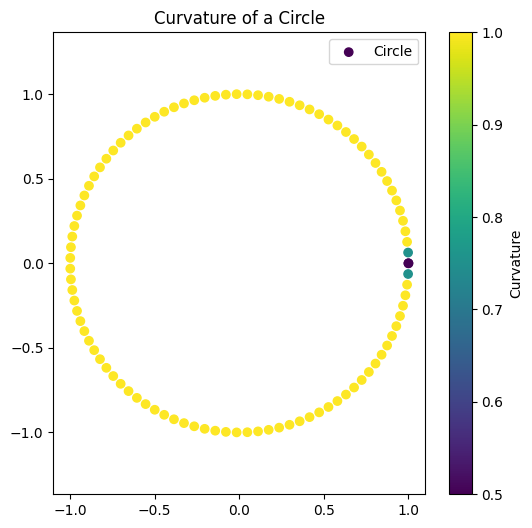

In [49]:
# Parametric circle
t = np.linspace(0, 2 * np.pi, 100)
x = np.cos(t)
y = np.sin(t)

curvature = compute_curvature_2d(x, y, t)

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(x, y, label="Circle", c=curvature.flatten(), cmap="viridis")  # Flatten the curvature array
plt.colorbar(label="Curvature")
plt.title("Curvature of a Circle")
plt.legend()
plt.axis("equal")
plt.show()

In [12]:
def bezier_curve(points, num_points=100):
    """
    Generate a Bezier curve from a set of control points.

    Parameters:
    points (list of tuples): Control points for the Bezier curve.
    num_points (int): Number of points to generate along the curve.

    Returns:
    tuple: x and y coordinates of the Bezier curve.
    """
    points = np.array(points)
    n = len(points) - 1
    t = np.linspace(0, 1, num_points)
    curve = np.array([(1 - t_i)**n * points[0] + 
                      sum(np.math.comb(n, k) * (t_i**k) * ((1 - t_i)**(n - k)) * points[k] for k in range(1, n + 1))
                      for t_i in t])
    
    return curve[:, 0], curve[:, 1]


def plot_curvature(x, y, curvature):    
    # Plot
    plt.figure(figsize=(6, 6))
    plt.plot(x, y, label="Circle")
    plt.scatter(x, y, c=curvature, cmap="viridis", label="Curvature")
    plt.colorbar(label="Curvature")
    plt.title("Curvature of a Circle")
    plt.legend()
    plt.axis("equal")
    plt.show()


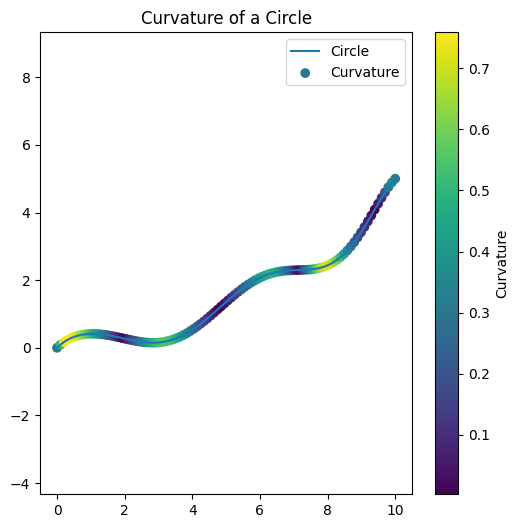

In [50]:
x,y = bezier_curve([(0, 0), (1, 1), (2, 0), (3, 1), (4, -3), (5, 1), (6, 7), (7, 1), (8, 0), (9, 4), (10, 5)])
curvature = compute_curvature_2d(x, y, t)
plot_curvature(x, y, curvature)

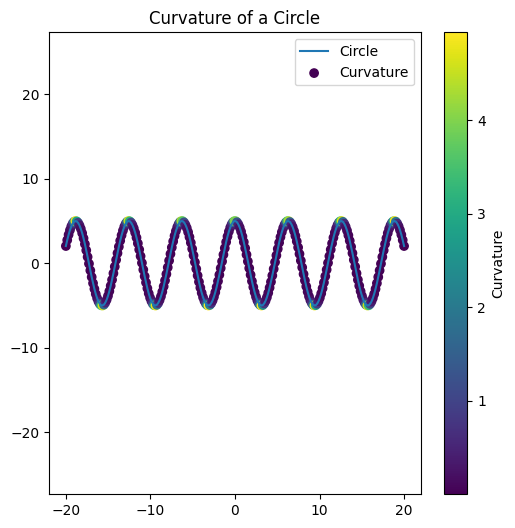

In [51]:
t = np.linspace(-20, 20, 250)
x = t
y = 5*np.cos(t)
curvature = compute_curvature_2d(x, y, t)
plot_curvature(x, y, curvature)

In [52]:
def compute_curvature_torsion_3d(x, y, z, t):
    # Compute derivatives
    dx = np.gradient(x, t)
    dy = np.gradient(y, t)
    dz = np.gradient(z, t)
    ddx = np.gradient(dx, t)
    ddy = np.gradient(dy, t)
    ddz = np.gradient(dz, t)
    dddx = np.gradient(ddx, t)
    dddy = np.gradient(ddy, t)
    dddz = np.gradient(ddz, t)

    # Tangent and normal vectors
    r_prime = np.array([dx, dy, dz])
    r_double_prime = np.array([ddx, ddy, ddz])
    r_triple_prime = np.array([dddx, dddy, dddz])

    # Curvature
    cross_r1_r2 = np.cross(r_prime.T, r_double_prime.T).T
    curvature = np.linalg.norm(cross_r1_r2, axis=0) / (np.linalg.norm(r_prime, axis=0)**3)

    # Torsion
    torsion = np.einsum('ij,ij->j', r_prime, np.cross(r_double_prime.T, r_triple_prime.T).T)
    torsion /= np.linalg.norm(cross_r1_r2, axis=0)**2

    return curvature, torsion

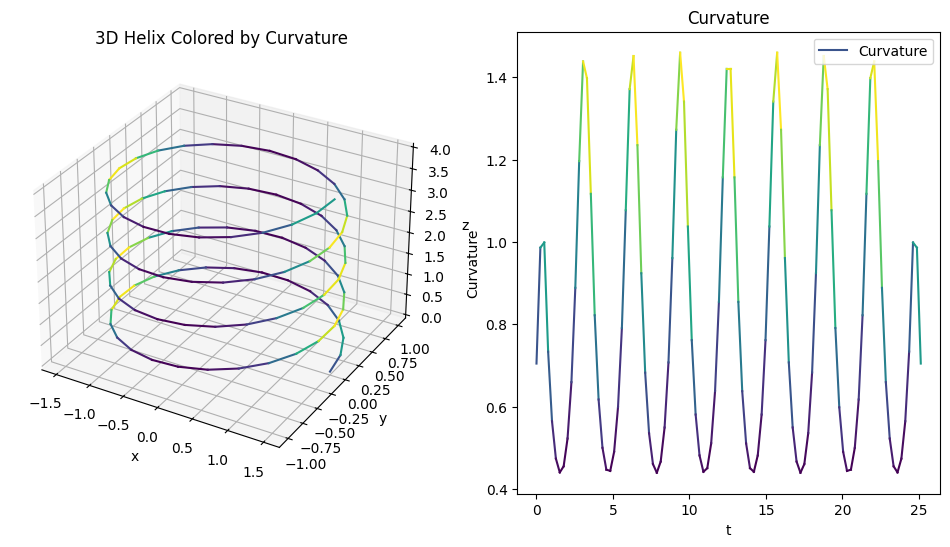

In [64]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
import numpy as np

# Helix parametric equation
t = np.linspace(0, 8 * np.pi, 100)
x = 1.5*np.cos(t)
y = np.sin(t)
z = t / (2 * np.pi)

# Example curvature and torsion (replace with actual computation)
curvature, torsion = compute_curvature_torsion_3d(x, y, z, t)

# Normalize curvature for colormap
norm = Normalize(vmin=np.min(curvature), vmax=np.max(curvature))
curvature_colors = plt.cm.viridis(norm(curvature))

# Plot
fig = plt.figure(figsize=(12, 6))

# 3D Helix plot with curvature coloring
ax = fig.add_subplot(121, projection='3d')
for i in range(len(t) - 1):
    ax.plot(x[i:i+2], y[i:i+2], z[i:i+2], color=curvature_colors[i])

ax.set_title("3D Helix Colored by Curvature")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

# Curvature and Torsion plot
ax2 = fig.add_subplot(122)
for i in range(len(t) - 1):  # Add segments with colors
    ax2.plot(t[i:i+2], curvature[i:i+2], color=curvature_colors[i])
    
ax2.set_title("Curvature")
ax2.set_xlabel("t")
ax2.set_ylabel("Curvature")
ax2.legend(["Curvature"])

plt.show()

In [69]:
def compute_surface_curvature(z, x, y):
    dz_dx, dz_dy = np.gradient(z, x, y)
    dz_dxx, dz_dxy = np.gradient(dz_dx, x, y)
    dz_dyy, dz_dyx = np.gradient(dz_dy, x, y)

    # Gaussian curvature
    numerator_gaussian = dz_dxx * dz_dyy - dz_dxy**2
    denominator_gaussian = (1 + dz_dx**2 + dz_dy**2)**2
    gaussian_curvature = numerator_gaussian / denominator_gaussian

    # Mean curvature
    numerator_mean = ((1 + dz_dx**2) * dz_dyy - 2 * dz_dx * dz_dy * dz_dxy + (1 + dz_dy**2) * dz_dxx)
    denominator_mean = 2 * (1 + dz_dx**2 + dz_dy**2)**(3/2)
    mean_curvature = numerator_mean / denominator_mean

    return gaussian_curvature, mean_curvature

In [72]:
gaussian_curvature.min(), gaussian_curvature.max()
# (-9.430473695190476e-15, 7.747127463608464e-15)

(-9.430473695190476e-15, 7.747127463608464e-15)

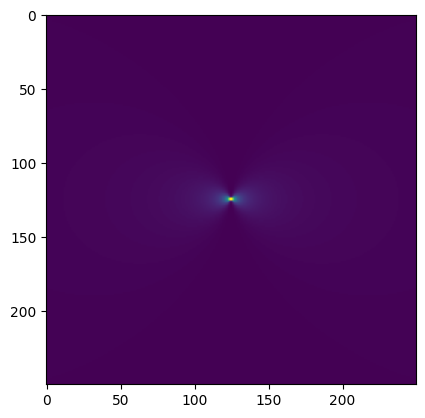

In [99]:
plt.imshow(curvature_colors)
plt.show()

gaussian_curvature spread: -2.3732105613035844e-14 7.487185339572048e-14
mean_curvature spread: -23.413024959834736 -2.8312262054480264e-06


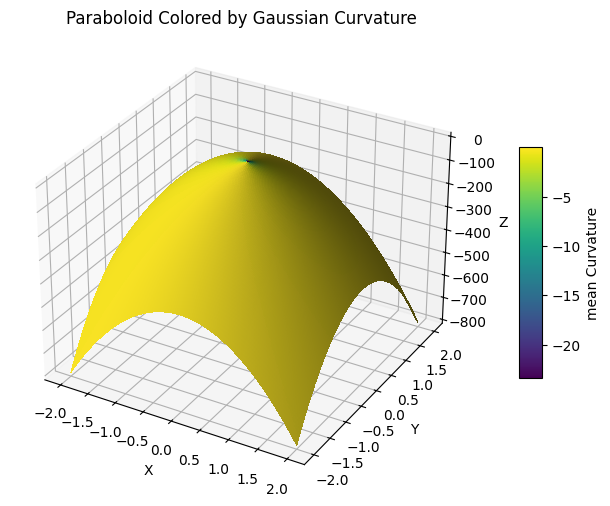

In [103]:
# Paraboloid
x = np.linspace(-2, 2, 250)
y = np.linspace(-2, 2, 250)
X, Y = np.meshgrid(x, y)
Z = -100*(X**2 + Y**2)

gaussian_curvature, mean_curvature = compute_surface_curvature(Z, x, y)

print('gaussian_curvature spread:', gaussian_curvature.min(), gaussian_curvature.max())
print('mean_curvature spread:', mean_curvature.min(), mean_curvature.max())

# Normalize Gaussian curvature for colormap

picked_curvature_name = 'mean'

if picked_curvature_name == 'gaussian':
    picked_curvature = gaussian_curvature
elif picked_curvature_name == 'mean':
    picked_curvature = mean_curvature

norm = Normalize(vmin=np.min(picked_curvature), vmax=np.max(picked_curvature))
curvature_colors = plt.cm.viridis(norm(picked_curvature))

# 3D Surface Plot Colored by Gaussian Curvature
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')

# Surface plot
surf = ax.plot_surface(X, Y, Z, facecolors=curvature_colors, #plt.cm.viridis(norm(gaussian_curvature)),
                        rstride=1, cstride=1, antialiased=False, linewidth=0)

# Colorbar
mappable = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
mappable.set_array(picked_curvature)
plt.colorbar(mappable, ax=ax, shrink=0.5, aspect=10, label=f"{picked_curvature_name} Curvature")

ax.set_title("Paraboloid Colored by Gaussian Curvature")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

In [ ]:

# Plot
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.contourf(X, Y, gaussian_curvature, cmap="viridis")
plt.colorbar(label="Gaussian Curvature")
plt.title("Gaussian Curvature")

plt.subplot(122)
plt.contourf(X, Y, mean_curvature, cmap="plasma")
plt.colorbar(label="Mean Curvature")
plt.title("Mean Curvature")

plt.show()

In [118]:
from scipy.interpolate import splprep, splev
import matplotlib.pyplot as plt

t = np.linspace(0, 1, 100)
x = np.sin(t)
y = np.cos(t)
z = t

tck, u = splprep([x, y, z], s=0)  # Parametric curve fitting
new_points = splev(u, tck)
dx, dy, dz = splev(u, tck, der=1)  # First derivative
ddx, ddy, ddz = splev(u, tck, der=2)  # Second derivative

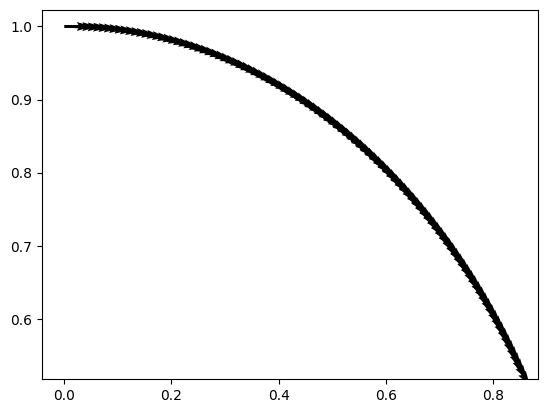

In [120]:
# plot vector field
fig, ax = plt.subplots()
ax.quiver(x, y, dx, dy)
plt.show()


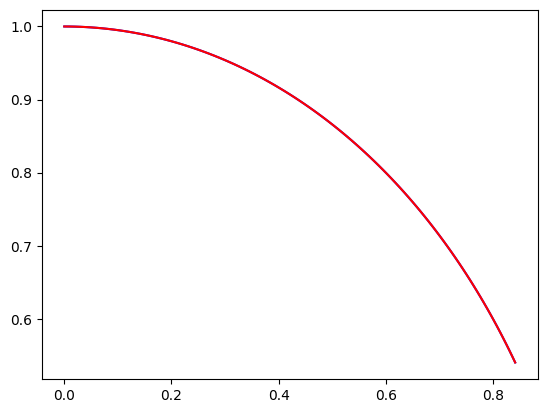

In [119]:
fig, ax = plt.subplots()
ax.plot(x, y, color='blue')
ax.plot(new_points[0], new_points[1], color='red')
plt.show()

/Users/solar/miniconda3/envs/pytorch/lib/python3.11/site-packages/pyvista/jupyter/notebook.py:37: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


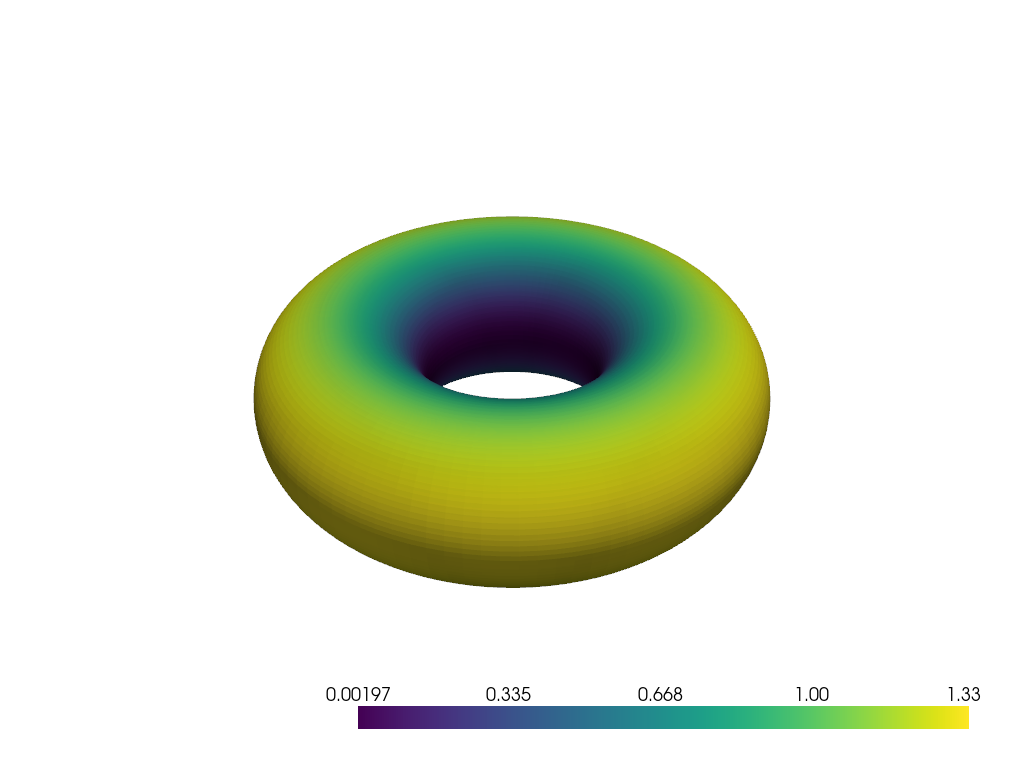

In [132]:
import pyvista as pv
mesh = pv.ParametricTorus()
curvature = mesh.curvature()
plotter = pv.Plotter()
# plotter.add_mesh(mesh, scalars="Curvature")
plotter.add_mesh(mesh, scalars=curvature)
plotter.show()

In [20]:
import numpy as np
import svgwrite
import random

def generate_random_svg_logo(filename="logo.svg", size=(100, 100)):
    """
    Generate a random SVG logo and save it to a file.

    Parameters:
    filename (str): The name of the file to save the SVG logo.
    size (tuple): The size of the SVG canvas (width, height).
    """
    dwg = svgwrite.Drawing(filename, profile='tiny', size=size)
    
    # Create random shapes
    for _ in range(random.randint(1, 5)):
        shape_type = random.choice(['circle', 'rect', 'line'])
        if shape_type == 'circle':
            dwg.add(dwg.circle(center=(random.randint(0, size[0]), random.randint(0, size[1])),
                               r=random.randint(5, 20),
                               fill=svgwrite.rgb(random.random(), random.random(), random.random())))
        elif shape_type == 'rect':
            dwg.add(dwg.rect(insert=(random.randint(0, size[0]), random.randint(0, size[1])),
                             size=(random.randint(10, 30), random.randint(10, 30)),
                             fill=svgwrite.rgb(random.random(), random.random(), random.random())))
        elif shape_type == 'line':
            dwg.add(dwg.line(start=(random.randint(0, size[0]), random.randint(0, size[1])),
                             end=(random.randint(0, size[0]), random.randint(0, size[1])),
                             stroke=svgwrite.rgb(random.random(), random.random(), random.random()), 
                             stroke_width=random.randint(1, 5)))
    
    dwg.save()

def svg_to_numpy(filename):
    """
    Convert an SVG file to a numpy array.

    Parameters:
    filename (str): The name of the SVG file to convert.

    Returns:
    np.ndarray: A numpy array representation of the SVG image.
    """
    from cairosvg import svg2png
    from PIL import Image

    # Convert SVG to PNG
    png_filename = filename.replace('.svg', '.png')
    svg2png(url=filename, write_to=png_filename)

    # Load PNG and convert to numpy array
    img = Image.open(png_filename)
    return np.array(img)


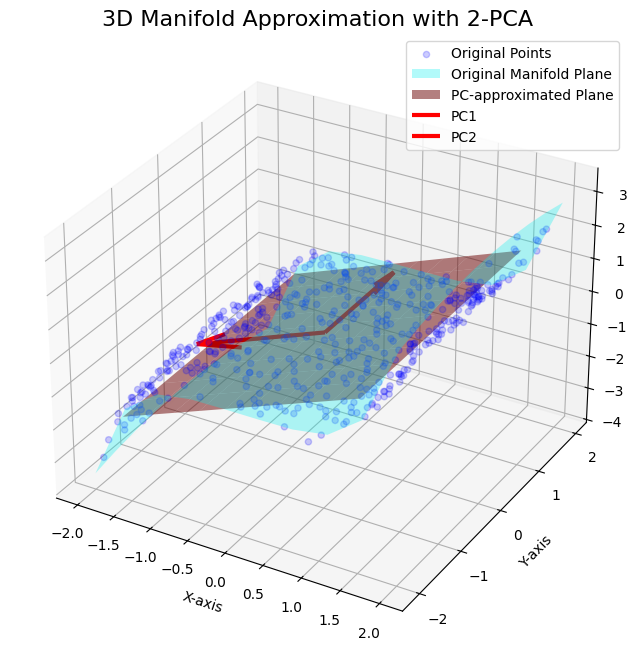

In [147]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

# Generate a slightly bended plane in 3D
np.random.seed(42)
n_points = 500
x = np.random.uniform(-2, 2, n_points)
y = np.random.uniform(-2, 2, n_points)
z = 0.1 * x**5 - 0.1 * y**2 + np.random.normal(0, 0.1, n_points)  # Slightly bended plane

points = np.vstack((x, y, z)).T

# Perform PCA to approximate the plane
pca = PCA(n_components=2)
pca.fit(points)
mean_point = pca.mean_
components = pca.components_
explained_variance = pca.explained_variance_

# Create a meshgrid for the PCA-approximated plane
u = np.linspace(-2, 2, 10)
v = np.linspace(-2, 2, 10)
U, V = np.meshgrid(u, v)
approximated_plane = (mean_point[None, :] +
                      U[..., None] * components[0] +
                      V[..., None] * components[1])

# Plot the results
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot original points
ax.scatter(points[:, 0], points[:, 1], points[:, 2], color='blue', alpha=0.2, label='Original Points')

# Plot original manifold plane
ax.plot_surface(U, V, 0.1 * U**5 - 0.1 * V**2, color='cyan', alpha=0.3, rstride=100, cstride=100, label='Original Manifold Plane')

# Plot PCA-approximated plane
ax.plot_surface(approximated_plane[:, :, 0], approximated_plane[:, :, 1], approximated_plane[:, :, 2],
                color='red', alpha=0.5)

# Plot PCA vectors
for i in range(2):
    start = mean_point
    end = mean_point + components[i] * np.sqrt(explained_variance[i]) * 1.5
    ax.quiver(start[0], start[1], start[2],
              end[0] - start[0], end[1] - start[1], end[2] - start[2],
              color='red', linewidth=3, label=f'PC{i+1}' if i == 0 else None)

# Enhance plot aesthetics
ax.set_title("3D Manifold Approximation with 2-PCA", fontsize=16)
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
ax.legend(['Original Points', 'Original Manifold Plane', 'PC-approximated Plane', 'PC1', 'PC2'], loc='upper right')
plt.show()
